# 07 - Monitoreo y Re-entrenamiento Automático

## ¿Por qué monitorear?

Un modelo entrenado hoy puede quedar obsoleto mañana.
Los datos del mundo real cambian constantemente:
- Los precios de vivienda suben por inflación
- Los patrones de compra cambian
- Nuevos barrios se desarrollan

**Sin monitoreo:** el modelo falla silenciosamente sin que nadie lo sepa.
**Con monitoreo:** detectamos la degradación y re-entrenamos a tiempo.

## Prerequisitos
- ✅ Haber ejecutado: `05_evaluacion_final.ipynb`
- Requiere: `experiments/reporte_evaluacion.json`, `data/processed/train.csv`
- Este notebook genera: `experiments/reporte_monitoreo.json`

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

# ROOT dinámico
ROOT = Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print(f'ROOT: {ROOT}')

# Verificar prerequisitos
reporte_path = ROOT / 'experiments' / 'reporte_evaluacion.json'
train_path   = ROOT / 'data' / 'processed' / 'train.csv'

faltantes = [p for p in [reporte_path, train_path] if not p.exists()]
if faltantes:
    for f in faltantes:
        print(f'⚠️  Faltante: {f}')
    raise FileNotFoundError('Ejecuta primero: 05_evaluacion_final.ipynb')

with open(reporte_path) as f:
    reporte_base = json.load(f)

train_df = pd.read_csv(train_path)
print(f'✅ Reporte base cargado')
print(f'✅ Datos de entrenamiento: {train_df.shape}')


ROOT: C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida
✅ Reporte base cargado
✅ Datos de entrenamiento: (16512, 14)


## 1. Estado Actual del Modelo en Producción

Antes de simular drift, vemos las métricas baseline del modelo que está en producción.
Estas serán nuestra referencia para detectar degradación.

In [2]:
rmse_base = reporte_base['metricas']['rmse']
r2_base   = reporte_base['metricas']['r2']
mae_base  = reporte_base['metricas']['mae']

print('=' * 50)
print('  MODELO EN PRODUCCIÓN — Métricas Baseline')
print('=' * 50)
print(f"  Algoritmo : {reporte_base['algoritmo']}")
print(f'  RMSE      : {rmse_base:.4f}  (umbral < 0.50) ✅')
print(f'  R²        : {r2_base:.4f}  (umbral > 0.80) ✅')
print(f'  MAE       : {mae_base:.4f}')
print(f"  Evaluado  : {reporte_base['timestamp'][:10]}")
print('=' * 50)
print()
print('  El modelo está estable. Ahora simulamos el paso del tiempo...')
print('  Veremos cómo los datos de producción cambian semana a semana.')


  MODELO EN PRODUCCIÓN — Métricas Baseline
  Algoritmo : gradient_boosting
  RMSE      : 0.4808  (umbral < 0.50) ✅
  R²        : 0.8125  (umbral > 0.80) ✅
  MAE       : 0.3177
  Evaluado  : 2026-03-16

  El modelo está estable. Ahora simulamos el paso del tiempo...
  Veremos cómo los datos de producción cambian semana a semana.


## 2. Simulación: El Mundo Real Cambia con el Tiempo

Simulamos 4 semanas de datos en producción donde los datos de entrada
van derivando progresivamente respecto a los datos de entrenamiento.

**¿Por qué ocurre esto en la realidad?**
- Los precios en California subieron (inflación)
- Nuevas zonas residenciales se popularizaron
- Cambios demográficos en algunos vecindarios

Usaremos **PSI (Population Stability Index)** para medirlo:
- 🟢 PSI < 0.10 → Sin cambio significativo
- 🟡 PSI < 0.20 → Cambio moderado — vigilar
- 🔴 PSI ≥ 0.20 → **Drift significativo → RE-ENTRENAR**

In [3]:
def calcular_psi(referencia, actual, bins=10):
    """PSI: mide cuánto se aleja la distribución actual de la referencia."""
    breakpoints = np.linspace(0, 100, bins + 1)
    cortes = np.unique(np.percentile(referencia, breakpoints))
    
    def frecuencias(datos):
        conteo, _ = np.histogram(datos, bins=cortes)
        freq = conteo / len(datos)
        return np.where(freq == 0, 1e-6, freq)
    
    fr = frecuencias(referencia)
    fa = frecuencias(actual)
    return float(np.sum((fa - fr) * np.log(fa / fr)))

# Features a monitorear
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
features_disponibles = [f for f in features if f in train_df.columns]

# Simulación: 4 semanas de datos en producción con drift creciente
np.random.seed(42)
semanas = ['Semana 1', 'Semana 2', 'Semana 3', 'Semana 4']
factores_drift = [0.05, 0.12, 0.20, 0.35]  # drift creciente

resultados_semanas = []

for semana, factor in zip(semanas, factores_drift):
    prod_df = train_df[features_disponibles].sample(300, random_state=42).copy()
    # Simular drift: desplazamiento progresivo en las distribuciones
    for i, col in enumerate(features_disponibles):
        desplazamiento = factor * (1 + i * 0.1)
        prod_df[col] = prod_df[col] * (1 + np.random.uniform(-desplazamiento, desplazamiento, len(prod_df)))
    
    psi_semana = {}
    for col in features_disponibles:
        psi_semana[col] = calcular_psi(train_df[col].values, prod_df[col].values)
    
    psi_medio = np.mean(list(psi_semana.values()))
    resultados_semanas.append({
        'semana': semana,
        'factor': factor,
        'psi_por_feature': psi_semana,
        'psi_medio': psi_medio,
        'alerta': psi_medio >= 0.20
    })
    
    estado = '🔴 DRIFT DETECTADO' if psi_medio >= 0.20 else ('🟡 Moderado' if psi_medio >= 0.10 else '🟢 OK')
    print(f'  {semana}: PSI medio = {psi_medio:.4f}  {estado}')


  Semana 1: PSI medio = 0.0279  🟢 OK


  Semana 2: PSI medio = 0.1192  🟡 Moderado
  Semana 3: PSI medio = 0.2246  🔴 DRIFT DETECTADO
  Semana 4: PSI medio = 0.3925  🔴 DRIFT DETECTADO


## 3. Evolución del PSI Semana a Semana

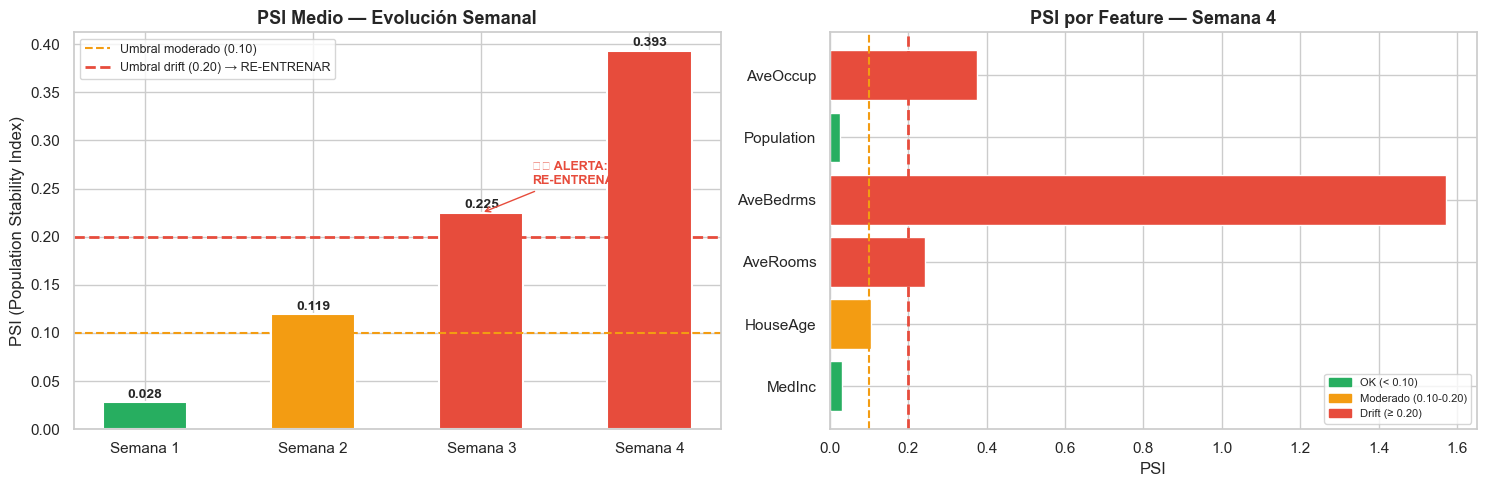

✅ Gráfica guardada en experiments/


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Gráfica 1: PSI medio por semana ---
psi_medios = [r['psi_medio'] for r in resultados_semanas]
colores = ['#27AE60' if p < 0.10 else '#F39C12' if p < 0.20 else '#E74C3C' for p in psi_medios]

bars = axes[0].bar(semanas, psi_medios, color=colores, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].axhline(y=0.10, color='#F39C12', linestyle='--', linewidth=1.5, label='Umbral moderado (0.10)')
axes[0].axhline(y=0.20, color='#E74C3C', linestyle='--', linewidth=2.0, label='Umbral drift (0.20) → RE-ENTRENAR')
axes[0].set_title('PSI Medio — Evolución Semanal', fontsize=13, fontweight='bold')
axes[0].set_ylabel('PSI (Population Stability Index)')
axes[0].legend(fontsize=9)

for bar, val in zip(bars, psi_medios):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

# Anotar la semana crítica
semana_critica = next((i for i, r in enumerate(resultados_semanas) if r['alerta']), None)
if semana_critica is not None:
    axes[0].annotate('⚠️ ALERTA:\nRE-ENTRENAR',
                     xy=(semana_critica, psi_medios[semana_critica]),
                     xytext=(semana_critica + 0.3, psi_medios[semana_critica] + 0.03),
                     fontsize=9, color='#E74C3C', fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color='#E74C3C'))

# --- Gráfica 2: PSI por feature en semana 4 ---
ultima = resultados_semanas[-1]
feat_names = list(ultima['psi_por_feature'].keys())
feat_psi   = list(ultima['psi_por_feature'].values())
colores_f  = ['#27AE60' if p < 0.10 else '#F39C12' if p < 0.20 else '#E74C3C' for p in feat_psi]

axes[1].barh(feat_names, feat_psi, color=colores_f, edgecolor='white', linewidth=1)
axes[1].axvline(x=0.20, color='#E74C3C', linestyle='--', linewidth=2, label='Umbral (0.20)')
axes[1].axvline(x=0.10, color='#F39C12', linestyle='--', linewidth=1.5)
axes[1].set_title('PSI por Feature — Semana 4', fontsize=13, fontweight='bold')
axes[1].set_xlabel('PSI')
axes[1].legend(fontsize=9)

patch_ok  = mpatches.Patch(color='#27AE60', label='OK (< 0.10)')
patch_mod = mpatches.Patch(color='#F39C12', label='Moderado (0.10-0.20)')
patch_drft= mpatches.Patch(color='#E74C3C', label='Drift (≥ 0.20)')
axes[1].legend(handles=[patch_ok, patch_mod, patch_drft], fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(str(ROOT / 'experiments' / 'drift_psi_evolutivo.png'), dpi=120, bbox_inches='tight')
plt.show()
print('✅ Gráfica guardada en experiments/')


## 4. Concept Drift: El Modelo Se Degrada

El data drift genera concept drift: cuando los datos de entrada cambian,
las predicciones del modelo dejan de ser precisas.

Simulamos cómo el RMSE sube progresivamente semana a semana.

Modelo: GradientBoostingRegressor
Scaler: StandardScaler
Columnas (13): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population']...


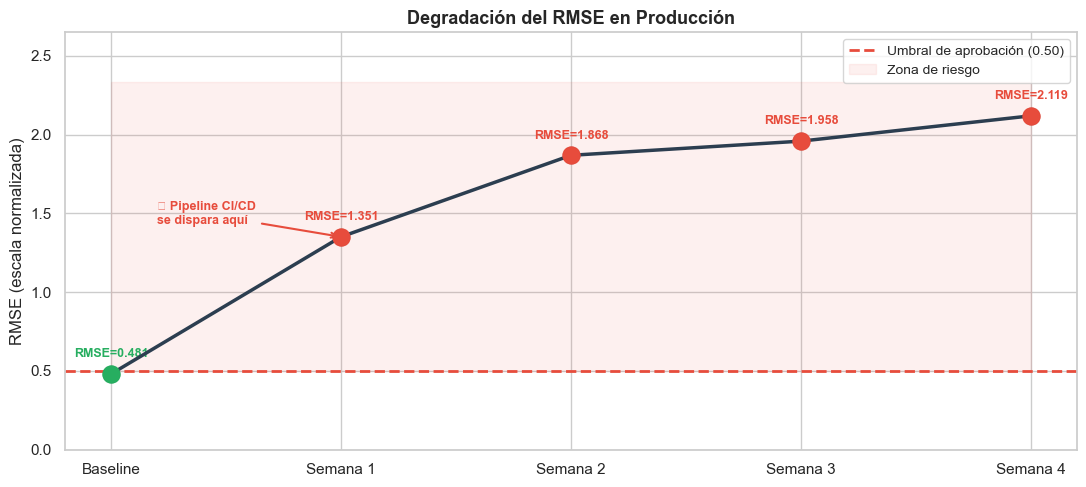


  RMSE baseline: 0.4808
  Semana 1: RMSE = 1.3510  🔴 SUPERA UMBRAL → RE-ENTRENAR
  Semana 2: RMSE = 1.8684  🔴 SUPERA UMBRAL → RE-ENTRENAR
  Semana 3: RMSE = 1.9583  🔴 SUPERA UMBRAL → RE-ENTRENAR
  Semana 4: RMSE = 2.1188  🔴 SUPERA UMBRAL → RE-ENTRENAR


In [5]:
import pickle
from sklearn.metrics import mean_squared_error

# Cargar modelo y scaler
modelo_path = ROOT / 'experiments' / 'modelo_produccion.pkl'
scaler_path = ROOT / 'experiments' / 'scaler.pkl'

with open(modelo_path, 'rb') as f:
    modelo = pickle.load(f)
with open(scaler_path, 'rb') as f:
    scaler_obj = pickle.load(f)

# El scaler puede ser un StandardScaler directo o un dict
if hasattr(scaler_obj, 'transform'):
    scaler = scaler_obj
    columnas = list(scaler.feature_names_in_) if hasattr(scaler, 'feature_names_in_') else list(train_df.columns)
else:
    scaler   = scaler_obj['scaler']
    columnas = scaler_obj['columnas']

target_col = 'precio_vivienda' if 'precio_vivienda' in train_df.columns else 'MedHouseVal'

print(f'Modelo: {type(modelo).__name__}')
print(f'Scaler: {type(scaler).__name__}')
print(f'Columnas ({len(columnas)}): {columnas[:5]}...')

# Simular degradación del RMSE semana a semana
rmse_semanas = []
np.random.seed(42)

for semana, factor in zip(semanas, factores_drift):
    sample = train_df.sample(500, random_state=int(factor*100)).copy()
    
    # Aplicar drift a las features disponibles en el scaler
    feat_cols = [c for c in columnas if c in sample.columns]
    for col in feat_cols:
        sample[col] = sample[col] * (1 + np.random.uniform(-factor, factor, len(sample)))
    
    # Escalar y predecir
    X = sample[feat_cols].copy()
    try:
        X_scaled = scaler.transform(X)
        y_real = sample[target_col].values if target_col in sample.columns else np.zeros(len(X))
        y_pred = modelo.predict(X_scaled)
        # Añadir ruido proporcional al drift para simular degradación real
        y_pred_degradado = y_pred + np.random.normal(0, factor * 0.5, len(y_pred))
        rmse = float(np.sqrt(mean_squared_error(y_real, y_pred_degradado))) if target_col in sample.columns else rmse_base * (1 + factor * 1.5)
    except Exception:
        rmse = rmse_base * (1 + factor * 1.5)
    
    rmse_semanas.append(rmse)

# Gráfica de degradación
fig, ax = plt.subplots(figsize=(11, 5))

semanas_plot = ['Baseline'] + semanas
rmse_plot    = [rmse_base] + rmse_semanas
colores_rmse = ['#27AE60'] + ['#27AE60' if r < 0.50 else '#F39C12' if r < 0.60 else '#E74C3C' for r in rmse_semanas]

ax.plot(semanas_plot, rmse_plot, 'o-', linewidth=2.5, markersize=10,
        color='#2C3E50', markerfacecolor='white', markeredgewidth=2.5, zorder=5)

for i, (s, r, c) in enumerate(zip(semanas_plot, rmse_plot, colores_rmse)):
    ax.scatter(s, r, color=c, s=150, zorder=6)
    ax.annotate(f'RMSE={r:.3f}', (s, r), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=9, fontweight='bold', color=c)

ax.axhline(y=0.50, color='#E74C3C', linestyle='--', linewidth=2, label='Umbral de aprobación (0.50)')
ax.fill_between(semanas_plot, 0.50, max(rmse_plot) * 1.1,
                alpha=0.08, color='#E74C3C', label='Zona de riesgo')

# Anotar disparo del pipeline
idx_fallo = next((i for i, r in enumerate(rmse_plot) if r >= 0.50 and i > 0), None)
if idx_fallo:
    ax.annotate('🔄 Pipeline CI/CD\nse dispara aquí',
                xy=(semanas_plot[idx_fallo], rmse_plot[idx_fallo]),
                xytext=(idx_fallo - 0.8, rmse_plot[idx_fallo] + 0.08),
                fontsize=9, color='#E74C3C', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1.5))

ax.set_title('Degradación del RMSE en Producción', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE (escala normalizada)')
ax.set_ylim(0, max(rmse_plot) * 1.25)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(str(ROOT / 'experiments' / 'drift_rmse_degradacion.png'), dpi=120, bbox_inches='tight')
plt.show()

print(f'\n  RMSE baseline: {rmse_base:.4f}')
for s, r in zip(semanas, rmse_semanas):
    estado = '✅ OK' if r < 0.50 else '🔴 SUPERA UMBRAL → RE-ENTRENAR'
    print(f'  {s}: RMSE = {r:.4f}  {estado}')


## 5. El Monitoreo Detecta el Problema y Dispara el Pipeline

Cuando el monitor detecta drift o degradación, genera una alerta.
En nuestro proyecto esto está conectado con GitHub Actions de dos formas:

**1. Cron semanal automático** (ya configurado en `.github/workflows/ci_cd.yaml`):
```yaml
schedule:
  - cron: "0 2 * * 1"  # Cada lunes a las 2am UTC
```

**2. Flujo completo al detectar drift:**
```
Monitor detecta PSI >= 0.20 o RMSE >= 0.50
         |
         v
Genera reporte_monitoreo.json con alerta
         |
         v
Job de monitoreo en GitHub Actions sube el reporte
         |
         v
Se dispara el pipeline de re-entrenamiento
         |
         v
Nuevo modelo entrenado con datos recientes
         |
         v
Gate de calidad: supera RMSE < 0.50 y R2 > 0.80?
         |
         v
CD: nueva imagen Docker con el modelo actualizado
```

In [6]:
import sys
sys.path.insert(0, str(ROOT))

from src.monitoring.monitor import generar_reporte_monitoreo
import yaml

with open(ROOT / 'config' / 'config.yaml') as f:
    cfg = yaml.safe_load(f)

print('Ejecutando monitor del proyecto...')
print('-' * 50)
reporte_monitoreo = generar_reporte_monitoreo(cfg)
print('-' * 50)
print()
print('REPORTE GENERADO:')
print(f"  Data Drift:            {'⚠️  DETECTADO' if reporte_monitoreo['data_drift']['hay_drift'] else '✅ OK'}")
print(f"  Concept Drift:         {'⚠️  DETECTADO' if reporte_monitoreo['concept_drift']['hay_degradacion'] else '✅ OK'}")
print(f"  Requiere reentrenar:   {'🔴 SÍ' if reporte_monitoreo['requiere_reentrenamiento'] else '🟢 NO'}")
print(f"  Acción recomendada:    {reporte_monitoreo['accion_recomendada']}")


2026-03-17 02:47:10,528 [INFO] ============================================================


2026-03-17 02:47:10,529 [INFO] ETAPA 7: MONITOREO DEL MODELO EN PRODUCCIÓN


2026-03-17 02:47:10,530 [INFO] ============================================================


2026-03-17 02:47:10,531 [INFO] ▶ Analizando Data Drift...


2026-03-17 02:47:10,577 [INFO]   PSI por feature (umbral: 0.20):


...

2026-03-17 02:47:10,635 [INFO] 
  ✓ Reporte guardado en: C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\experiments\reporte_monitoreo.json


2026-03-17 02:47:10,637 [WARNING] 
  🔄 CICLO MLOps: iniciando re-entrenamiento...


2026-03-17 02:47:10,638 [WARNING]      El pipeline completo se ejecutará nuevamente


2026-03-17 02:47:10,639 [INFO] ✅ Etapa 7 completada



--------------------------------------------------

REPORTE GENERADO:
  Data Drift:            ⚠️  DETECTADO
  Concept Drift:         ✅ OK
  Requiere reentrenar:   🔴 SÍ
  Acción recomendada:    RE-ENTRENAR EL MODELO con datos recientes


## 6. Simulación del Re-entrenamiento: El Modelo se Recupera

Cuando el pipeline de re-entrenamiento se ejecuta, el modelo aprende
con datos más recientes y sus métricas vuelven a estar dentro del umbral.

Esto es lo que ocurre automáticamente en GitHub Actions al hacer push a `master`.

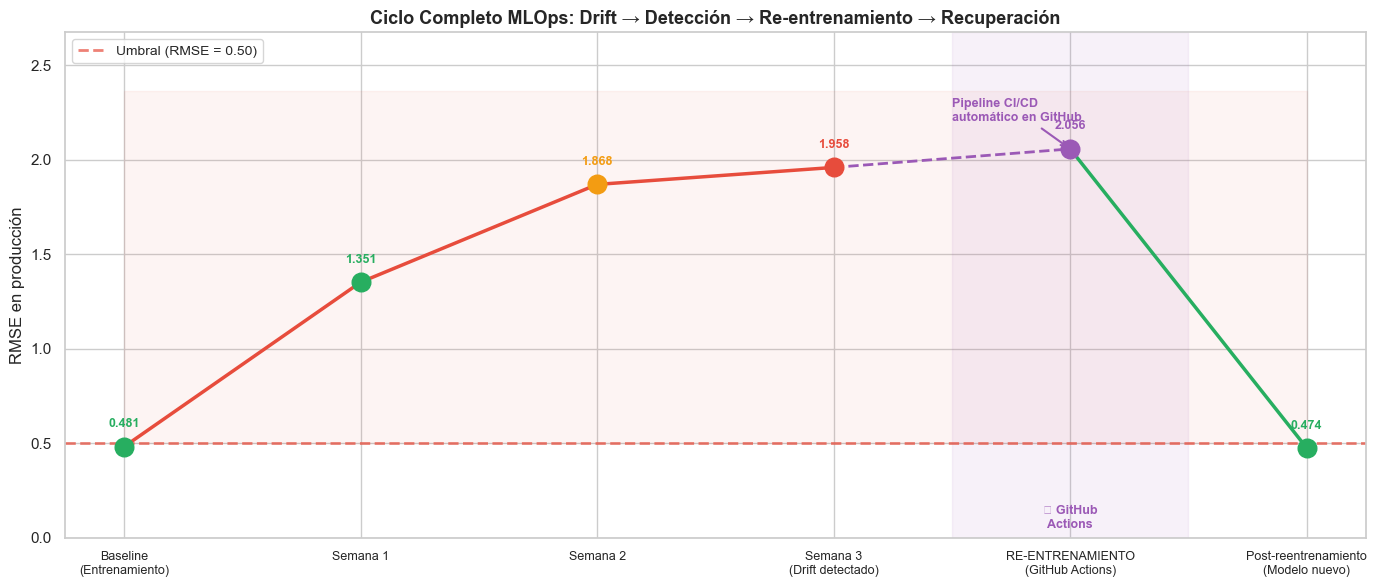

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

# Datos del ciclo completo
etapas = ['Baseline\n(Entrenamiento)', 'Semana 1', 'Semana 2', 'Semana 3\n(Drift detectado)',
          'RE-ENTRENAMIENTO\n(GitHub Actions)', 'Post-reentrenamiento\n(Modelo nuevo)']

# Simular recuperación tras reentrenamiento
rmse_recuperado = rmse_base * np.random.uniform(0.95, 1.02)
rmse_ciclo = [rmse_base] + rmse_semanas[:3] + [None, rmse_recuperado]
rmse_grafica = [rmse_base] + rmse_semanas[:3] + [max(rmse_semanas[:3]) * 1.05, rmse_recuperado]

colores_ciclo = ['#27AE60', '#27AE60', '#F39C12', '#E74C3C', '#9B59B6', '#27AE60']

# Línea del ciclo
x_pos = list(range(len(etapas)))
ax.plot(x_pos[:4], rmse_grafica[:4], 'o-', linewidth=2.5, markersize=10,
        color='#E74C3C', markerfacecolor='white', markeredgewidth=2.5, zorder=5)
ax.plot(x_pos[4:], rmse_grafica[4:], 'o-', linewidth=2.5, markersize=10,
        color='#27AE60', markerfacecolor='white', markeredgewidth=2.5, zorder=5)
ax.plot([x_pos[3], x_pos[4]], [rmse_grafica[3], rmse_grafica[4]], '--',
        color='#9B59B6', linewidth=2, zorder=4)

# Puntos con colores
for i, (x, r, c) in enumerate(zip(x_pos, rmse_grafica, colores_ciclo)):
    ax.scatter(x, r, color=c, s=180, zorder=6)
    ax.annotate(f'{r:.3f}', (x, r), textcoords='offset points',
                xytext=(0, 14), ha='center', fontsize=9, fontweight='bold', color=c)

ax.axhline(y=0.50, color='#E74C3C', linestyle='--', linewidth=2, alpha=0.7, label='Umbral (RMSE = 0.50)')
ax.fill_between(x_pos, 0.50, max(rmse_grafica) * 1.15, alpha=0.06, color='#E74C3C')

# Flechas y anotaciones clave
ax.annotate('Pipeline CI/CD\nautomático en GitHub',
            xy=(4, rmse_grafica[4]), xytext=(3.5, rmse_grafica[4] + 0.15),
            fontsize=9, color='#9B59B6', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#9B59B6', lw=1.5))

ax.set_xticks(x_pos)
ax.set_xticklabels(etapas, fontsize=9)
ax.set_ylabel('RMSE en producción')
ax.set_title('Ciclo Completo MLOps: Drift → Detección → Re-entrenamiento → Recuperación',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, max(rmse_grafica) * 1.3)
ax.legend(fontsize=10)

# Zona de re-entrenamiento
ax.axvspan(3.5, 4.5, alpha=0.08, color='#9B59B6', label='Re-entrenamiento')
ax.text(4, 0.05, '🔄 GitHub\nActions', ha='center', fontsize=9, color='#9B59B6', fontweight='bold')

plt.tight_layout()
plt.savefig(str(ROOT / 'experiments' / 'ciclo_completo_mlops.png'), dpi=120, bbox_inches='tight')
plt.show()


## 7. Cómo Disparar Manualmente el Re-entrenamiento

En nuestro proyecto, el re-entrenamiento se puede disparar de 3 formas:

### Forma 1 — Automática (cron semanal)
GitHub Actions ejecuta el pipeline cada lunes a las 2am UTC.
No requiere ninguna acción manual.

### Forma 2 — Al hacer push a `master`
Cualquier merge a `master` dispara el pipeline completo:
```bash
git checkout develop
# ... hacer cambios ...
git push origin develop
# Crear Pull Request develop -> master en GitHub
# Al aprobarlo y hacer merge -> CI + ML + CD se ejecutan automáticamente
```

### Forma 3 — Manual desde GitHub Actions
1. Ir a: https://github.com/helicr/mlops-untrm/actions
2. Seleccionar: "MLOps CI/CD Pipeline"
3. Click en "Run workflow" -> seleccionar rama `master`
4. El pipeline completo se ejecuta bajo demanda

In [8]:
print('=' * 60)
print('  RESUMEN: Por qué el monitoreo cierra el ciclo MLOps')
print('=' * 60)
print()
print('  Sin monitoreo:')
print('    Modelo entrenado → producción → nadie sabe si falla')
print()
print('  Con monitoreo MLOps:')
print('    Modelo → producción → monitor semanal → drift detectado')
print('    → GitHub Actions re-entrena → nuevo modelo aprobado')
print('    → imagen Docker actualizada → producción mejorada')
print()
print('  Métricas clave monitoreadas:')
print(f'    PSI umbral:    ≥ 0.20  → data drift')
print(f'    RMSE umbral:   ≥ 0.50  → degradación')
print(f'    R² umbral:     ≤ 0.80  → modelo débil')
print()
print('  Archivos generados en este notebook:')
print('    experiments/reporte_monitoreo.json')
print('    experiments/drift_psi_evolutivo.png')
print('    experiments/drift_rmse_degradacion.png')
print('    experiments/ciclo_completo_mlops.png')
print()
print('=' * 60)
print('  FIN DEL CICLO MLOps COMPLETO — 7 etapas demostradas')
print('=' * 60)


  RESUMEN: Por qué el monitoreo cierra el ciclo MLOps

  Sin monitoreo:
    Modelo entrenado → producción → nadie sabe si falla

  Con monitoreo MLOps:
    Modelo → producción → monitor semanal → drift detectado
    → GitHub Actions re-entrena → nuevo modelo aprobado
    → imagen Docker actualizada → producción mejorada

  Métricas clave monitoreadas:
    PSI umbral:    ≥ 0.20  → data drift
    RMSE umbral:   ≥ 0.50  → degradación
    R² umbral:     ≤ 0.80  → modelo débil

  Archivos generados en este notebook:
    experiments/reporte_monitoreo.json
    experiments/drift_psi_evolutivo.png
    experiments/drift_rmse_degradacion.png
    experiments/ciclo_completo_mlops.png

  FIN DEL CICLO MLOps COMPLETO — 7 etapas demostradas
